<a href="https://colab.research.google.com/github/tvishaaprabhu/air_quality_project/blob/main/air_quality_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classroom Air Quality — Mumbai (real pilot data, end-to-end)

**AI-Driven Prediction of Classroom Air Quality for Underserved Schools: A Satellite-Informed Framework and Healthy Classroom Environmental Index (HCEI)**

This notebook now runs on the **real pilot sensor data** (`Sensor_Data_Pilot_.xlsx`, 10 stations, 15 Jun – 30 Aug 2026). It:

1. Loads and cleans the 10 station sheets, resamples the irregular readings to a clean hourly series.
2. Pulls matching **outdoor predictors from Google Earth Engine** (CAMS PM2.5/PM10, MAIAC AOD, TROPOMI NO2/CO, ERA5-Land weather, static urban-morphology).
3. Trains **XGBoost** models — PM2.5 & PM10 from satellite+weather; **CO2 separately** from time/occupancy (no satellite, by design).
4. Validates with **leave-one-classroom-out** and a **temporal hold-out**, then builds the **HCEI**.
5. Exports **six publication-quality figures** (PNG @300 dpi + PDF) and results CSVs.

**Read before running the results:**
- The pilot spans the **monsoon** (Jun–Aug): outdoor PM is low and rain-scavenged, so indoor PM2.5 sits in a narrow ~11–16 µg/m³ band. Expect **modest R²** — limited signal, not a code fault.
- Two stations (Saboo School & Saboo Jr) share the **same coordinates**, so they get identical satellite features; leave-one-classroom-out on them is not a true unseen-location test. Both are kept, as requested.
- The low-cost sensors write `"offline"` when down and report quantized integer values; treat readings as uncalibrated ground truth for now (calibration is a documented next step).

**Setup:** a free Earth Engine account + a Google Cloud **project id** (config cell). Then Runtime → Run all, and upload the Excel when prompted.


In [ ]:
# 1) Install extras Colab doesn't ship with
!pip -q install earthengine-api xgboost shap geemap openpyxl 2>/dev/null
print("installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 25.2 MB/s eta 0:00:00
installed


In [ ]:
# 2) CONFIG + load the pilot Excel  (edit EE_PROJECT and, if needed, FILENAME)
EE_PROJECT   = "air-quality-508413"   # <-- your Earth Engine / Google Cloud project id
FILENAME     = "Sensor_Data_Pilot_.xlsx"      # the pilot workbook
TZ           = "Asia/Kolkata"
SCHOOL_HOURS = (8, 15)
RANDOM_SEED  = 42

import os, numpy as np, pandas as pd
np.random.seed(RANDOM_SEED)

# upload the file if it isn't already in the Colab session
if not os.path.exists(FILENAME):
    try:
        from google.colab import files
        FILENAME = list(files.upload().keys())[0]
    except Exception:
        raise FileNotFoundError("Upload Sensor_Data_Pilot_.xlsx, or set FILENAME to its path.")

raw_sheets = pd.read_excel(FILENAME, sheet_name=None)   # dict {sheet: DataFrame}

# Build the school list straight from the sheets (id, name, coords) -> C01..C10
rows=[]
for i,(sheet,d) in enumerate(raw_sheets.items(),1):
    d.columns=[c.strip() for c in d.columns]
    rows.append({"classroom_id":f"C{i:02d}","name":str(d["Location"].iloc[0]),
                 "sheet":sheet,"lat":float(d["Latitude"].iloc[0]),"lon":float(d["Longitude"].iloc[0])})
schools_df=pd.DataFrame(rows)

# Auto-detect the 2.5-month window from the data
all_ts=pd.concat([pd.to_datetime(d["Timestamp"],errors="coerce") for d in raw_sheets.values()])
START_DATE=all_ts.min().strftime("%Y-%m-%d")
END_DATE=(all_ts.max().normalize()+pd.Timedelta(days=1)).strftime("%Y-%m-%d")   # exclusive
print("Study window:",START_DATE,"->",END_DATE)
schools_df[["classroom_id","name","lat","lon"]]

Saving Sensor Data Pilot .xlsx to Sensor Data Pilot  (1).xlsx
Study window: 2026-06-15 -> 2026-08-31


,classroom_id,name,lat,lon
0,C01,Vatsalya,18.989516,72.824211
1,C02,Bandra School,19.053849,72.834321
2,C03,Saboo Siddiqui School,18.967988,72.831398
3,C04,Saboo Siddiqui Jr. College,18.967988,72.831398
4,C05,Babasaheb Gawde English Medium School,19.002381,72.819610
5,C06,Maratha Mandir Worli Night High School,18.998515,72.817355
6,C07,Mahatma Gandhi School,19.143706,72.837064
7,C08,Rameshwar Vidya Mandir,19.084253,72.852760
8,C09,Access Life - Guru Nanak Niwas Centre,19.054540,72.890623
9,C10,Access Life - Diamond Garden Centre,19.053198,72.900502


In [ ]:
# 3) Connect to Earth Engine
import ee
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=EE_PROJECT)
print("Earth Engine ready.")

Earth Engine ready.


## Section 1 — Pull outdoor predictors from Earth Engine

Time-series sampled at each school with `getRegion`. Coarse pollutant products are aggregated to **daily**; ERA5-Land weather stays **hourly**. Satellite gaps become blanks — XGBoost handles missing values.

In [ ]:
# helpers
points_fc = ee.FeatureCollection(
    [ee.Feature(ee.Geometry.Point([r.lon, r.lat]), {"classroom_id": r.classroom_id})
     for r in schools_df.itertuples()])
region = points_fc.geometry().bounds().buffer(5000)

def extract_ts(ic, bands, scale):
    out=[]
    for r in schools_df.itertuples():
        pt=ee.Geometry.Point([r.lon,r.lat])
        try:
            data=ic.select(bands).getRegion(pt,scale).getInfo()
        except Exception as e:
            print(f"   {r.classroom_id}: {e}"); continue
        cols=data[0]; d=pd.DataFrame(data[1:],columns=cols)
        if d.empty: continue
        d["datetime"]=(pd.to_datetime(d["time"],unit="ms",utc=True)
                        .dt.tz_convert(TZ).dt.tz_localize(None).dt.floor("h"))
        d["classroom_id"]=r.classroom_id
        for b in bands: d[b]=pd.to_numeric(d[b],errors="coerce")
        out.append(d[["classroom_id","datetime"]+bands])
    return pd.concat(out,ignore_index=True) if out else pd.DataFrame(columns=["classroom_id","datetime"]+bands)

def to_daily(df,bands):
    d=df.copy(); d["date"]=d["datetime"].dt.floor("D")
    return d.groupby(["classroom_id","date"],as_index=False)[bands].mean()

start,end=ee.Date(START_DATE),ee.Date(END_DATE)

In [ ]:
# --- Daily pollutant proxies ---
print("CAMS PM2.5 / PM10 ...")
cams=(ee.ImageCollection("ECMWF/CAMS/NRT").filterDate(start,end)
      .filter(ee.Filter.eq("model_forecast_hour",0)))   # if empty, remove this filter
cb=["particulate_matter_d_less_than_25_um_surface","particulate_matter_d_less_than_10_um_surface"]
cams_df=extract_ts(cams,cb,40000)
if not cams_df.empty:
    cams_df[cb]=cams_df[cb]*1e9
    cams_df=cams_df.rename(columns={cb[0]:"pm25_out",cb[1]:"pm10_out"})
    cams_daily=to_daily(cams_df,["pm25_out","pm10_out"])
else:
    cams_daily=pd.DataFrame(columns=["classroom_id","date","pm25_out","pm10_out"])

def optional_daily(ic,bands,scale,newname,factor=1.0):
    try:
        d=extract_ts(ic,bands,scale)
        if d.empty: raise ValueError("no data")
        d[bands[0]]=d[bands[0]]*factor
        return to_daily(d.rename(columns={bands[0]:newname}),[newname])
    except Exception as e:
        print("  (skipped)",newname,e); return pd.DataFrame(columns=["classroom_id","date",newname])

print("MAIAC AOD ...")
aod_daily=optional_daily(ee.ImageCollection("MODIS/061/MCD19A2_GRANULES").filterDate(start,end).filterBounds(region),
                         ["Optical_Depth_055"],1000,"aod",0.001)
print("Sentinel-5P NO2 ...")
no2_daily=optional_daily(ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_NO2").filterDate(start,end).filterBounds(region),
                         ["tropospheric_NO2_column_number_density"],7000,"no2")
print("Sentinel-5P CO ...")
co_daily=optional_daily(ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_CO").filterDate(start,end).filterBounds(region),
                        ["CO_column_number_density"],7000,"co")

from functools import reduce
daily=reduce(lambda a,b:pd.merge(a,b,on=["classroom_id","date"],how="outer"),
             [cams_daily,aod_daily,no2_daily,co_daily])
for col in ["pm25_out","pm10_out","aod","no2","co"]:
    if col not in daily: daily[col]=np.nan
print("daily proxy rows:",len(daily))

CAMS PM2.5 / PM10 ...
MAIAC AOD ...
Sentinel-5P NO2 ...
Sentinel-5P CO ...
daily proxy rows: 780


In [ ]:
# --- Hourly weather (ERA5-Land) --- slowest step (~1-3 min)
print("ERA5-Land hourly weather ...")
era=ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY").filterDate(start,end)
eb=["temperature_2m","dewpoint_temperature_2m","u_component_of_wind_10m",
    "v_component_of_wind_10m","total_precipitation_hourly"]
met=extract_ts(era,eb,11132)
met["temp_out"]=met["temperature_2m"]-273.15
tC,tdC=met["temp_out"],met["dewpoint_temperature_2m"]-273.15
es=6.112*np.exp(17.62*tC/(243.12+tC)); e=6.112*np.exp(17.62*tdC/(243.12+tdC))
met["rh_out"]=(100*e/es).clip(0,100)
met["wind"]=np.hypot(met["u_component_of_wind_10m"],met["v_component_of_wind_10m"])
met["precip"]=met["total_precipitation_hourly"]*1000.0
met=met[["classroom_id","datetime","temp_out","rh_out","wind","precip"]]
print("weather rows:",len(met))

ERA5-Land hourly weather ...
weather rows: 18480


In [ ]:
# --- Static urban-morphology (one value per school) ---
print("Static morphology (NDVI, elevation, population, night-lights) ...")
def safe(fn,name):
    try: return fn()
    except Exception as e: print("  (skipped)",name,e); return None
s2=safe(lambda:(ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED").filterDate(start,end).filterBounds(region)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE",40)).median()
        .normalizedDifference(["B8","B4"]).rename("ndvi")),"ndvi")
elev=ee.Image("USGS/SRTMGL1_003").select("elevation").rename("elevation")
pop=safe(lambda:ee.ImageCollection("JRC/GHSL/P2023A/GHS_POP")
        .filter(ee.Filter.date("2020-01-01","2021-01-01")).first()
        .select("population_count").rename("population"),"population")
ntl=safe(lambda:ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMCFG")
        .filterDate("2024-01-01","2024-12-31").select("avg_rad").median().rename("ntl"),"ntl")
static_img=ee.Image.cat([x for x in [s2,elev,pop,ntl] if x is not None])
feats=static_img.reduceRegions(points_fc,ee.Reducer.mean(),100).getInfo()["features"]
static_df=pd.DataFrame([{"classroom_id":f["properties"]["classroom_id"],
                         **{k:f["properties"].get(k) for k in ["ndvi","elevation","population","ntl"]}}
                        for f in feats])
for col in ["ndvi","elevation","population","ntl"]:
    if col not in static_df: static_df[col]=np.nan
static_df

Static morphology (NDVI, elevation, population, night-lights) ...


,classroom_id,ndvi,elevation,population,ntl
0,C01,0.117082,9,162.426956,64.430000
1,C02,0.203840,10,934.376770,60.840000
2,C03,0.107391,15,768.656738,72.010002
3,C04,0.107391,15,768.656738,72.010002
4,C05,0.215073,4,188.440369,66.025002
5,C06,0.141080,8,734.106384,72.789993
6,C07,0.172638,16,834.630859,53.385002
7,C08,0.174662,7,630.142517,45.690002
8,C09,0.236200,12,628.408569,54.805000
9,C10,0.373437,14,523.038818,49.385002


## Section 2 — Load the real indoor data & merge

Each station sheet is cleaned (`"offline"` → missing), the irregular ~hourly readings are **floored to the hour and averaged**, then joined to the outdoor predictors.

In [ ]:
# clean + hourly-resample every station sheet
num_map={"temp_current":"temp_in","humidity_value":"rh_in","co2_value":"co2_ppm",
         "pm25_value":"pm25_in","pm10":"pm10_in"}
frames=[]
for r in schools_df.itertuples():
    d=raw_sheets[r.sheet].copy(); d.columns=[c.strip() for c in d.columns]
    d["datetime"]=pd.to_datetime(d["Timestamp"],errors="coerce").dt.floor("h")
    for c in num_map: d[c]=pd.to_numeric(d[c],errors="coerce")     # 'offline' -> NaN
    d=d.rename(columns=num_map)[["datetime"]+list(num_map.values())].dropna(subset=["datetime"])
    d=d.groupby("datetime",as_index=False).mean(numeric_only=True)  # avg within the hour
    d["classroom_id"]=r.classroom_id
    frames.append(d)
indoor=pd.concat(frames,ignore_index=True)
print("indoor hourly rows:",len(indoor))
print(indoor.groupby("classroom_id")[["co2_ppm","pm25_in","pm10_in"]].apply(lambda x:x.notna().sum()))

# merge outdoor onto the observed indoor rows
df=indoor.copy(); df["date"]=df["datetime"].dt.floor("D")
df=(df.merge(met,on=["classroom_id","datetime"],how="left")
      .merge(daily,on=["classroom_id","date"],how="left")
      .merge(static_df,on="classroom_id",how="left")
      .sort_values(["classroom_id","datetime"]).reset_index(drop=True))
for c in ["temp_out","rh_out","wind","precip","pm25_out","pm10_out","aod","no2","co"]:
    df[c]=df.groupby("classroom_id")[c].transform(lambda s:s.ffill().bfill())

# ---- To re-run later without Earth Engine: save/reload the merged table ----
# df.to_csv("merged_dataset.csv", index=False)
# df = pd.read_csv("merged_dataset.csv", parse_dates=["datetime","date"])

indoor hourly rows: 18480
              co2_ppm  pm25_in  pm10_in
classroom_id                           
C01              1717     1717     1717
C02              1848     1848     1848
C03              1848     1848     1848
C04              1812     1812     1812
C05              1848     1848     1848
C06              1848     1848     1848
C07              1848     1848     1848
C08              1848     1848     1848
C09              1848     1848     1848
C10              1848     1848     1848


## Sections 3–4 — Feature engineering

**classroom_id is not a predictor** (it can't generalise to an unsensored room) and **indoor CO2 is not used to predict PM** (that would leak into the leave-one-classroom-out test). The satellite + weather + morphology + time features are what *would* be known at a school with no sensor.

In [ ]:
h=df["datetime"].dt.hour; dow=df["datetime"].dt.dayofweek
df["is_school"]=((h>=SCHOOL_HOURS[0])&(h<SCHOOL_HOURS[1])&(dow<=5)).astype(int)   # Mon-Sat
df["hour"]=h; df["dow"]=dow; df["month"]=df["datetime"].dt.month
df["pm25_out_roll3"]=df.groupby("classroom_id")["pm25_out"].transform(lambda s:s.rolling(3,min_periods=1).mean())

PM_FEATURES=["pm25_out","pm10_out","aod","no2","co","temp_out","rh_out","wind","precip",
             "ndvi","elevation","population","ntl","hour","dow","month","is_school","pm25_out_roll3"]
CO2_FEATURES=["hour","dow","month","is_school","temp_out","rh_out","wind"]
TARGETS=[("pm25_in",PM_FEATURES,"PM$_{2.5}$","µg/m³"),
         ("pm10_in",PM_FEATURES,"PM$_{10}$","µg/m³"),
         ("co2_ppm",CO2_FEATURES,"CO₂","ppm")]
print("modelling rows:",len(df))

modelling rows: 18480


## Sections 5–6 — Models & validation

XGBoost per target. **Temporal hold-out** (last 25% of the period) tests forecasting; **leave-one-classroom-out** tests the sensor-free case. Rows with a missing value for a given target are dropped only for that target's model.

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

def metrics(y,p): return dict(RMSE=mean_squared_error(y,p)**.5,MAE=mean_absolute_error(y,p),
                              R2=r2_score(y,p),Bias=(p-y).mean())
def new_model(): return XGBRegressor(n_estimators=400,max_depth=5,learning_rate=0.05,subsample=.9,
                                     colsample_bytree=.9,random_state=RANDOM_SEED,n_jobs=-1)

tmin,tmax=df.datetime.min(),df.datetime.max(); cut=tmin+(tmax-tmin)*0.75
models,temporal,tests={},{},{}
for tgt,feats,lab,unit in TARGETS:
    sub=df.dropna(subset=[tgt])
    tr,te=sub[sub.datetime<cut],sub[sub.datetime>=cut]
    m=new_model(); m.fit(tr[feats],tr[tgt]); models[tgt]=m; tests[tgt]=te
    temporal[tgt]=metrics(te[tgt].values,m.predict(te[feats]))
print("Temporal hold-out:"); print(pd.DataFrame(temporal).T.round(3))

loco_rows=[]
for tgt,feats,lab,unit in TARGETS:
    sub=df.dropna(subset=[tgt]).reset_index(drop=True)
    gkf=GroupKFold(n_splits=sub.classroom_id.nunique())
    for trI,teI in gkf.split(sub,sub[tgt],sub["classroom_id"]):
        m=new_model(); m.fit(sub.iloc[trI][feats],sub.iloc[trI][tgt]); p=m.predict(sub.iloc[teI][feats])
        loco_rows.append({"target":tgt,"classroom":sub.iloc[teI]["classroom_id"].iloc[0],
                          **metrics(sub.iloc[teI][tgt].values,p)})
loco=pd.DataFrame(loco_rows)
print("\nLeave-one-classroom-out (mean):"); print(loco.groupby("target")[["RMSE","MAE","R2"]].mean().round(3))

pd.DataFrame(temporal).T.round(3).to_csv("metrics_temporal.csv")
loco.round(3).to_csv("metrics_loco.csv",index=False)

Temporal hold-out:
            RMSE     MAE     R2   Bias
pm25_in    1.011   0.819 -0.868 -0.632
pm10_in    1.607   1.304 -0.868 -1.015
co2_ppm  144.244  55.629 -0.009  8.963

Leave-one-classroom-out (mean):
           RMSE     MAE      R2
target                         
co2_ppm  99.497  65.216 -33.706
pm10_in   1.928   1.391   0.687
pm25_in   1.315   0.930   0.705


In [ ]:
# PM2.5 vs simple baselines (temporal test)
sub=df.dropna(subset=["pm25_in"]); tr,te=sub[sub.datetime<cut],sub[sub.datetime>=cut]
cams_base=metrics(te.pm25_in.values,te.pm25_out.values)
clim=tr.groupby("hour")["pm25_in"].mean()
clim_base=metrics(te.pm25_in.values,te.hour.map(clim).values)
print("PM2.5 — model vs baselines:")
print(pd.DataFrame({"XGBoost":temporal["pm25_in"],"CAMS raw":cams_base,"Hour climatology":clim_base}).T.round(3))

PM2.5 — model vs baselines:
                   RMSE    MAE      R2   Bias
XGBoost           1.011  0.819  -0.868 -0.632
CAMS raw          2.346  1.676  -9.055  0.411
Hour climatology  3.453  3.373 -20.788 -3.373


## Section 7 — Publication-quality figures

Consistent styling, 300 dpi, saved as **PNG + PDF**.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":300,"savefig.bbox":"tight",
    "font.size":11,"font.family":"DejaVu Sans","axes.titlesize":12,"axes.titleweight":"bold",
    "axes.labelsize":11,"axes.edgecolor":"#444","axes.linewidth":.9,"axes.grid":True,
    "grid.color":"#e9e9e9","grid.linewidth":.8,"legend.frameon":False,
    "figure.facecolor":"white","axes.facecolor":"white","xtick.color":"#333","ytick.color":"#333"})
C={"obs":"#2b2b2b","pred":"#0072B2","pm":"#0072B2","co2":"#D55E00","bar":"#4C78A8"}
TIER={"High risk":"#D55E00","Moderate":"#E69F00","Healthy":"#2E9E5B"}
def despine(ax):
    for s in ["top","right"]: ax.spines[s].set_visible(False)
def savefig(fig,name): fig.savefig(f"{name}.png"); fig.savefig(f"{name}.pdf"); plt.show()
nm=schools_df.set_index("classroom_id")["name"].to_dict()
short=lambda s:(s[:20]+"…") if len(s)>21 else s
LABELS={"pm25_out":"Outdoor PM₂.₅ (CAMS)","pm10_out":"Outdoor PM₁₀ (CAMS)","aod":"Aerosol optical depth",
        "no2":"NO₂ (satellite)","co":"CO (satellite)","temp_out":"Outdoor temperature","rh_out":"Outdoor humidity",
        "wind":"Wind speed","precip":"Precipitation","ndvi":"Vegetation (NDVI)","elevation":"Elevation",
        "population":"Population density","ntl":"Night-time lights","hour":"Hour of day","dow":"Day of week",
        "month":"Month","is_school":"School-hours flag","pm25_out_roll3":"Outdoor PM₂.₅ (3-h mean)"}

In [ ]:
# Full out-of-fold leave-one-classroom-out predictions for PM2.5
# (each school predicted by a model trained ONLY on the other nine -> honest full-period series)
subpm=df.dropna(subset=["pm25_in"]).reset_index(drop=True)
gkf=GroupKFold(n_splits=subpm.classroom_id.nunique()); oof=np.full(len(subpm),np.nan)
for trI,teI in gkf.split(subpm,subpm["pm25_in"],subpm["classroom_id"]):
    m=new_model(); m.fit(subpm.iloc[trI][PM_FEATURES],subpm.iloc[trI]["pm25_in"])
    oof[teI]=m.predict(subpm.iloc[teI][PM_FEATURES])
subpm["pm25_pred"]=oof
print("out-of-fold LOCO predictions ready:",subpm["pm25_pred"].notna().sum(),"rows")

out-of-fold LOCO predictions ready: 18313 rows


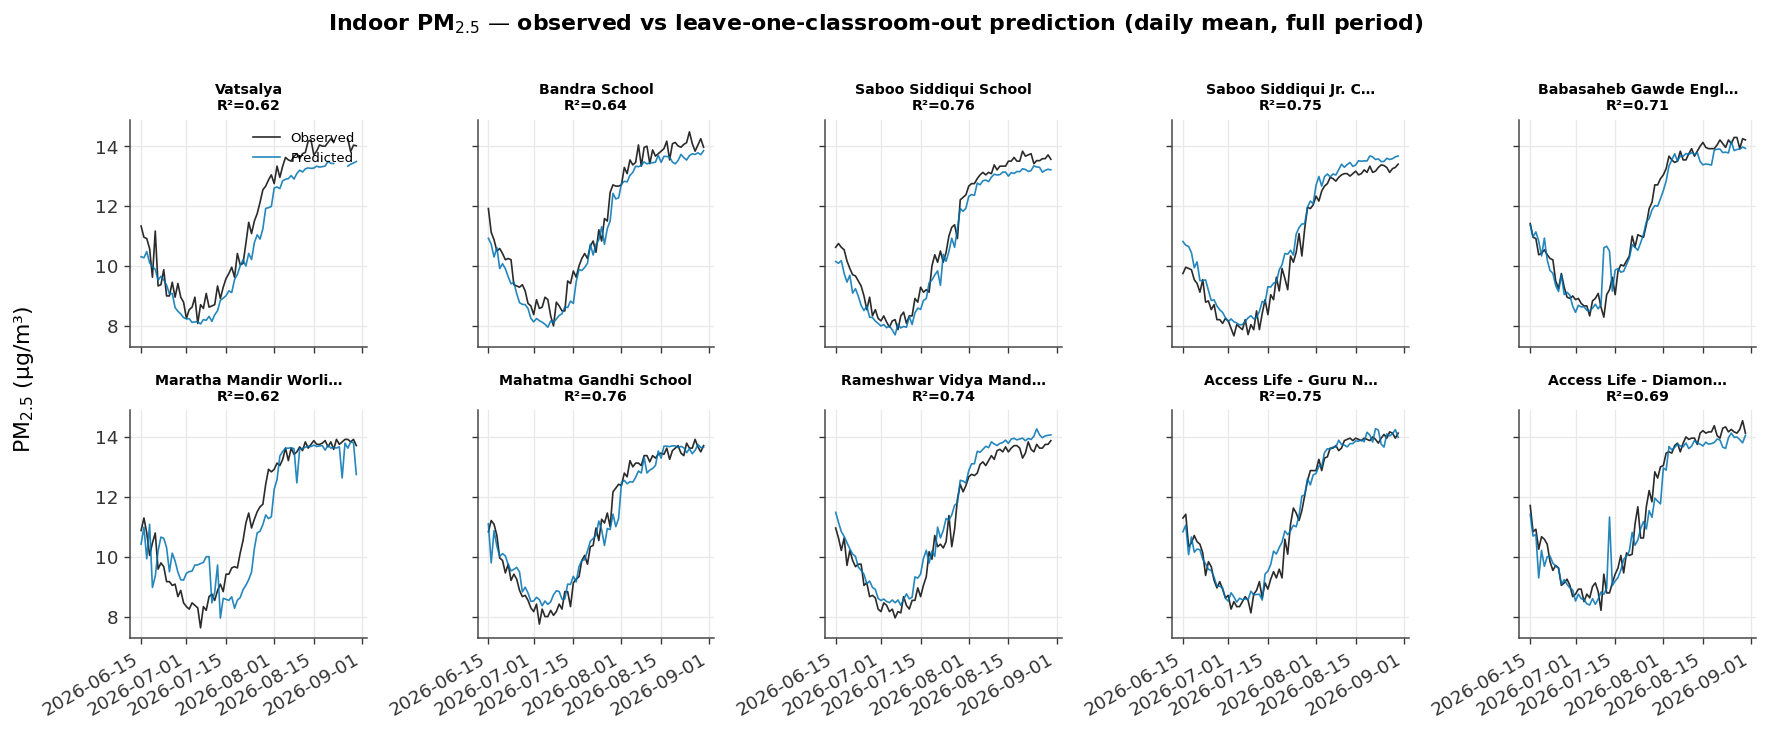

In [ ]:
# Fig 1 — observed vs LOCO-predicted PM2.5 for ALL schools (daily mean, full period)
fig,axs=plt.subplots(2,5,figsize=(15,6),sharex=True,sharey=True)
for ax,cid in zip(axs.ravel(),schools_df.classroom_id):
    g=subpm[subpm.classroom_id==cid].set_index("datetime").sort_index()
    go=g["pm25_in"].resample("D").mean(); gp=g["pm25_pred"].resample("D").mean()
    ax.plot(go.index,go,color=C["obs"],lw=1,label="Observed")
    ax.plot(gp.index,gp,color=C["pred"],lw=1,alpha=.85,label="Predicted")
    ax.set_title(f"{short(nm[cid])}\nR²={r2_score(g['pm25_in'],g['pm25_pred']):.2f}",fontsize=8.5)
    despine(ax)
axs[0,0].legend(loc="upper right",fontsize=8)
fig.suptitle("Indoor PM$_{2.5}$ — observed vs leave-one-classroom-out prediction (daily mean, full period)",
             fontweight="bold",y=1.01)
fig.supylabel("PM$_{2.5}$ (µg/m³)"); fig.autofmt_xdate(); fig.tight_layout()
savefig(fig,"fig1_grid_loco_pm25")

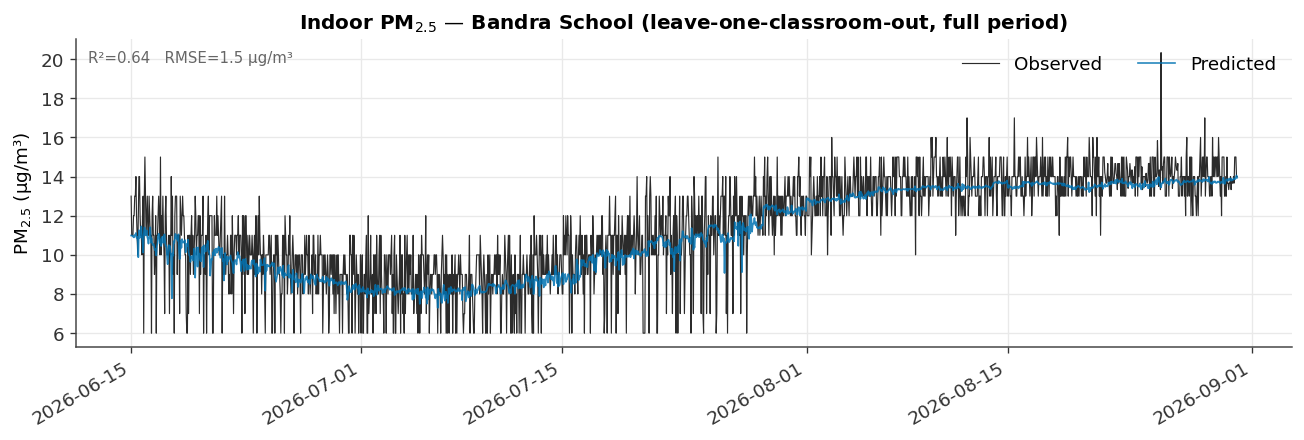

In [ ]:
# Fig 2 — observed vs LOCO-predicted PM2.5 for Bandra School (hourly, full period)
bid=schools_df[schools_df.name.str.contains("Bandra",case=False)]["classroom_id"].iloc[0]
b=subpm[subpm.classroom_id==bid].sort_values("datetime")
r2=r2_score(b.pm25_in,b.pm25_pred); rmse=mean_squared_error(b.pm25_in,b.pm25_pred)**.5
fig,ax=plt.subplots(figsize=(11,3.8))
ax.plot(b.datetime,b.pm25_in,color=C["obs"],lw=.7,label="Observed")
ax.plot(b.datetime,b.pm25_pred,color=C["pred"],lw=1,alpha=.85,label="Predicted")
ax.set_title(f"Indoor PM$_{{2.5}}$ — {nm[bid]} (leave-one-classroom-out, full period)")
ax.set_ylabel("PM$_{2.5}$ (µg/m³)")
ax.text(.01,.96,f"R²={r2:.2f}   RMSE={rmse:.1f} µg/m³",transform=ax.transAxes,va="top",fontsize=9,color="#666")
ax.legend(loc="upper right",ncol=2); despine(ax); fig.autofmt_xdate(); fig.tight_layout()
savefig(fig,"fig2_loco_bandra_pm25")

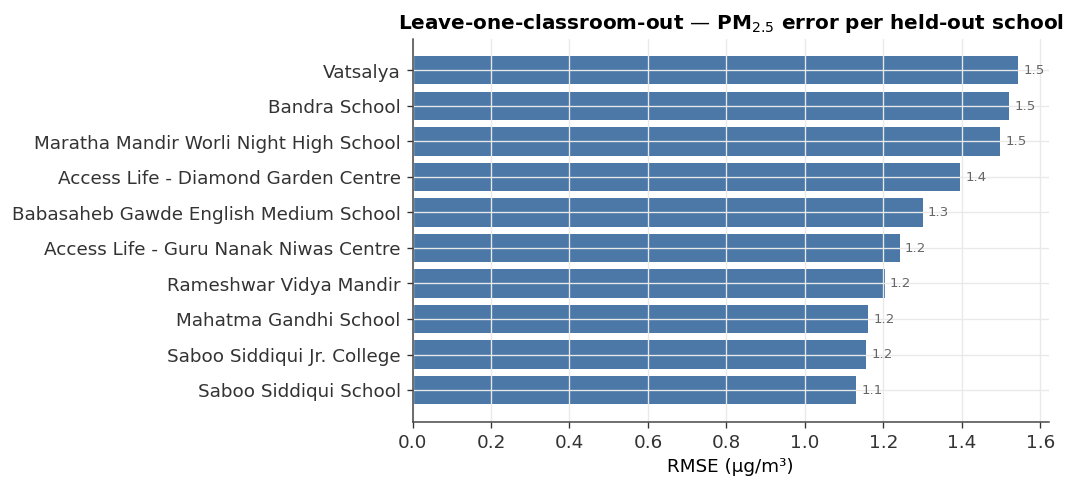

In [ ]:
# Fig 3 — leave-one-classroom-out PM2.5 error per held-out school
lp=loco[loco.target=="pm25_in"].copy(); lp["name"]=lp.classroom.map(nm); lp=lp.sort_values("RMSE")
fig,ax=plt.subplots(figsize=(9,4.2))
b=ax.barh(lp["name"],lp.RMSE,color=C["bar"]); ax.bar_label(b,fmt="%.1f",padding=3,fontsize=8,color="#666")
ax.set_xlabel("RMSE (µg/m³)"); ax.set_title("Leave-one-classroom-out — PM$_{2.5}$ error per held-out school")
despine(ax); fig.tight_layout(); savefig(fig,"fig3_loco_pm25")

/tmp/ipykernel_3144/3249578413.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  fig=plt.figure(figsize=(7.5,5)); shap.summary_plot(sv,samp,plot_type="bar",show=False,color=C["bar"])


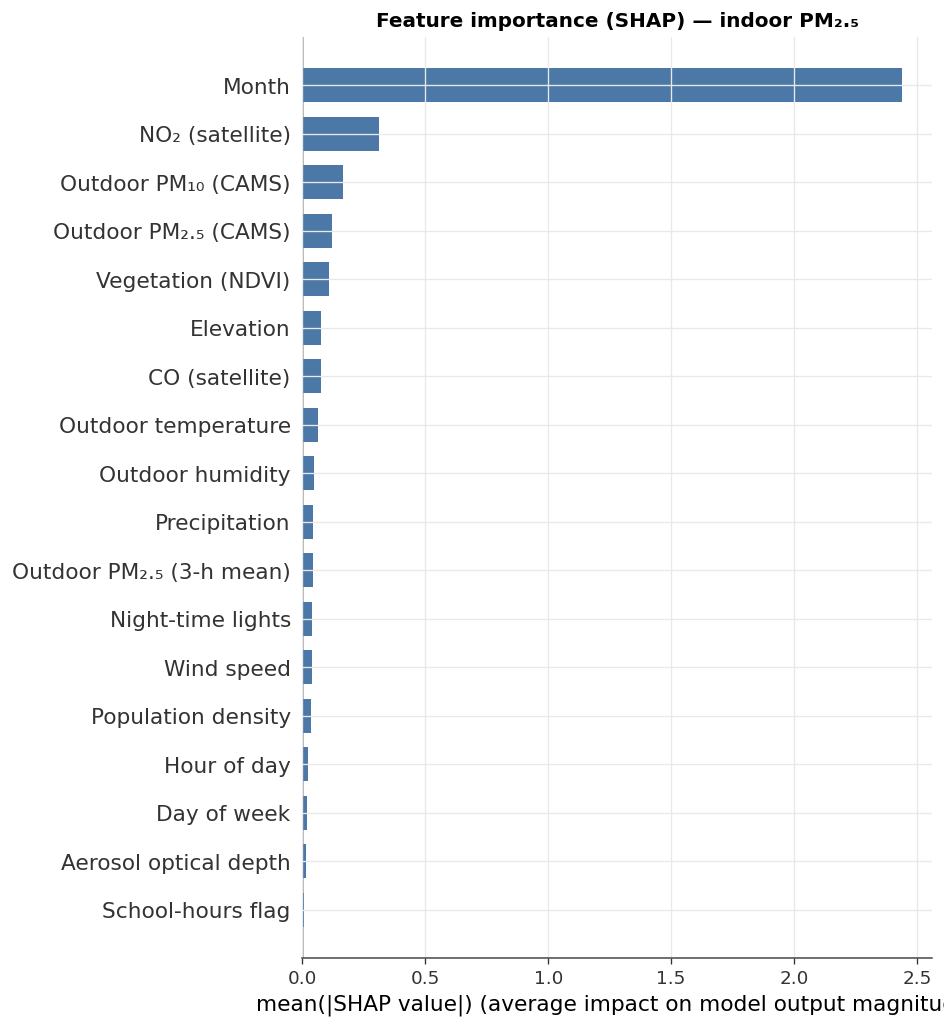

In [ ]:
# Fig 4 — feature importance (SHAP) for the PM2.5 model (plain-English labels)
try:
    import shap
    te=tests["pm25_in"]; samp=te[PM_FEATURES].sample(min(1000,len(te)),random_state=1)
    sv=shap.TreeExplainer(models["pm25_in"]).shap_values(samp)
    samp=samp.rename(columns=LABELS)                     # readable names for the figure
    fig=plt.figure(figsize=(7.5,5)); shap.summary_plot(sv,samp,plot_type="bar",show=False,color=C["bar"])
    plt.title("Feature importance (SHAP) — indoor PM₂.₅",fontweight="bold"); plt.tight_layout()
    plt.savefig("fig4_shap_pm25.png",dpi=300,bbox_inches="tight"); plt.savefig("fig4_shap_pm25.pdf",bbox_inches="tight"); plt.show()
except Exception as ex:
    print("SHAP unavailable, using gain importance:",ex)
    imp=pd.Series(models["pm25_in"].feature_importances_,
                  index=[LABELS.get(f,f) for f in PM_FEATURES]).sort_values()
    fig,ax=plt.subplots(figsize=(7.5,5)); ax.barh(imp.index,imp.values,color=C["bar"])
    ax.set_title("Feature importance — indoor PM₂.₅"); despine(ax); fig.tight_layout()
    savefig(fig,"fig4_importance_pm25")

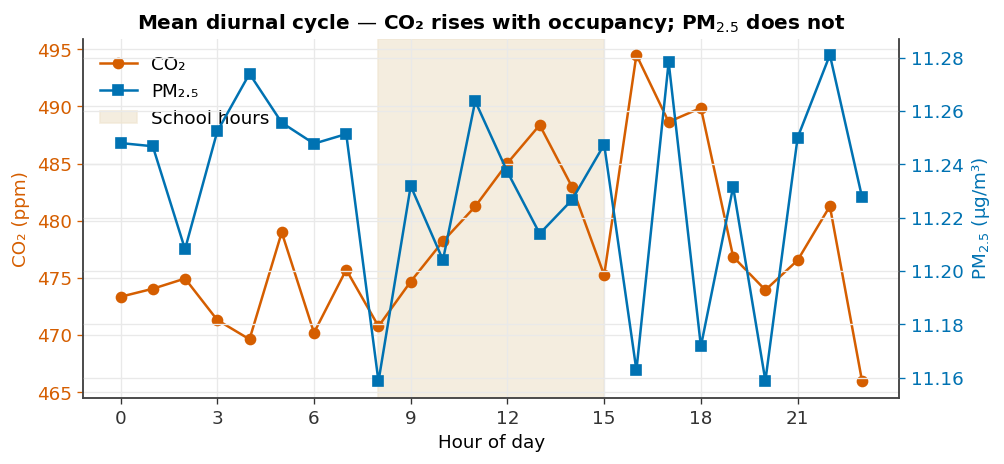

In [ ]:
# Fig 5 — mean diurnal cycle: CO2 (occupancy-driven) vs PM2.5
prof=df.groupby("hour")[["co2_ppm","pm25_in"]].mean()
fig,ax1=plt.subplots(figsize=(8.5,4))
sh_patch=ax1.axvspan(SCHOOL_HOURS[0],SCHOOL_HOURS[1],color="#f0e6d2",alpha=.7,label="School hours",zorder=0)
l1,=ax1.plot(prof.index,prof.co2_ppm,"o-",color=C["co2"],label="CO₂")
ax1.set_xlabel("Hour of day"); ax1.set_ylabel("CO₂ (ppm)",color=C["co2"]); ax1.tick_params(axis="y",colors=C["co2"])
ax2=ax1.twinx(); l2,=ax2.plot(prof.index,prof.pm25_in,"s-",color=C["pm"],label="PM₂.₅")
ax2.set_ylabel("PM$_{2.5}$ (µg/m³)",color=C["pm"]); ax2.tick_params(axis="y",colors=C["pm"])
ax1.set_title("Mean diurnal cycle — CO₂ rises with occupancy; PM$_{2.5}$ does not")
ax1.spines["top"].set_visible(False); ax2.spines["top"].set_visible(False)
ax1.set_xticks(range(0,24,3)); ax1.legend(handles=[l1,l2,sh_patch],loc="upper left")
fig.tight_layout(); savefig(fig,"fig5_diurnal")

## Section 8 — Healthy Classroom Environmental Index (HCEI)

Each parameter is scored 0–100 against a health guideline (WHO 2021 for PM, an 800–2000 ppm ventilation scale for CO2, comfort bands for temp/RH), weighted into one index (higher = healthier). Weights are in `W` — change and re-run to test sensitivity. Uses observed school-hour means; deploy with *predicted* values for rooms without sensors.

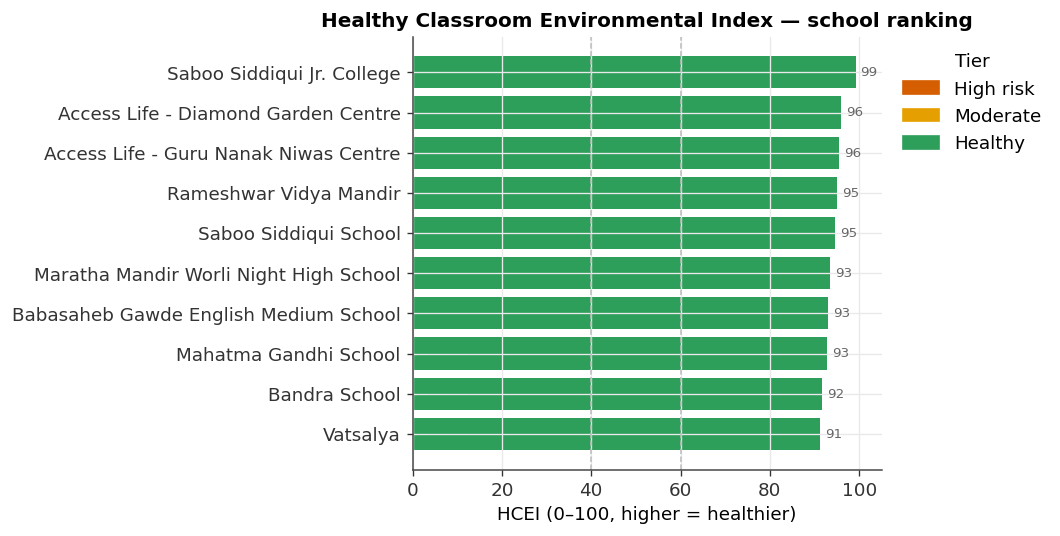

,name,HCEI,tier
classroom_id,,,
C01,Vatsalya,91.3,Healthy
C02,Bandra School,91.6,Healthy
C07,Mahatma Gandhi School,92.7,Healthy
C05,Babasaheb Gawde English Medium School,93.1,Healthy
C06,Maratha Mandir Worli Night High School,93.5,Healthy
C03,Saboo Siddiqui School,94.6,Healthy
C08,Rameshwar Vidya Mandir,95.1,Healthy
C09,Access Life - Guru Nanak Niwas Centre,95.5,Healthy
C10,Access Life - Diamond Garden Centre,95.9,Healthy


In [ ]:
sh=df[df.is_school==1].groupby("classroom_id")[["pm25_in","pm10_in","co2_ppm","temp_in","rh_in"]].mean()
def sub_lin(v,g,b): return np.clip(100*(b-v)/(b-g),0,100)
def sub_band(v,lo,hi,sp):
    below=np.clip(100*(1-(lo-v)/sp),0,100); above=np.clip(100*(1-(v-hi)/sp),0,100)
    return np.where(v<lo,below,np.where(v>hi,above,100))
idx=pd.DataFrame(index=sh.index)
idx["PM2.5"]=sub_lin(sh.pm25_in,15,75); idx["PM10"]=sub_lin(sh.pm10_in,45,150)
idx["CO2"]=sub_lin(sh.co2_ppm,800,2000); idx["Temp"]=sub_band(sh.temp_in,22,28,8); idx["RH"]=sub_band(sh.rh_in,30,60,25)
W={"PM2.5":0.30,"PM10":0.20,"CO2":0.30,"Temp":0.10,"RH":0.10}     # adjustable weights
HCEI=(idx*pd.Series(W)).sum(axis=1)
res=pd.DataFrame({"HCEI":HCEI}).join(sh).sort_values("HCEI"); res["name"]=res.index.map(nm)
res["tier"]=pd.cut(res.HCEI,[0,40,60,100],labels=["High risk","Moderate","Healthy"])
res.round(1).to_csv("hcei_ranking.csv")

# Fig 6 — HCEI ranking (full 0–100 axis)
fig,ax=plt.subplots(figsize=(9,4.6))
b=ax.barh(res["name"],res.HCEI,color=[TIER[t] for t in res.tier])
ax.bar_label(b,fmt="%.0f",padding=3,fontsize=8,color="#666")
ax.axvline(40,ls="--",lw=.9,color="#bbb"); ax.axvline(60,ls="--",lw=.9,color="#bbb")
ax.set_xlim(0,105); ax.set_xlabel("HCEI (0–100, higher = healthier)")
ax.set_title("Healthy Classroom Environmental Index — school ranking")
ax.legend(handles=[Patch(color=c,label=l) for l,c in TIER.items()],
          loc="upper left",bbox_to_anchor=(1.01,1),title="Tier")
despine(ax); fig.tight_layout(); savefig(fig,"fig6_hcei")
res[["name","HCEI","tier"]].round(1)

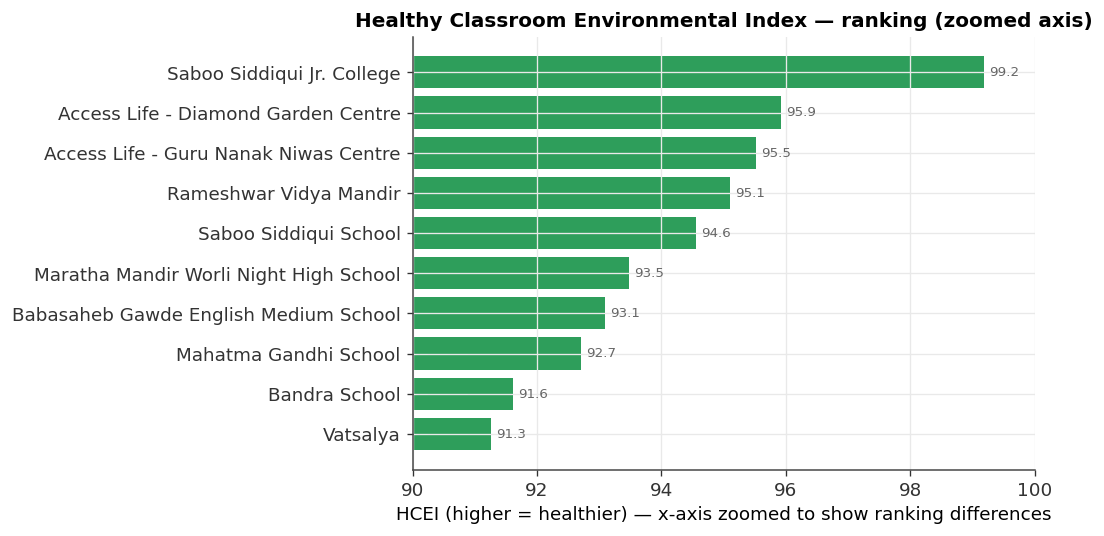

In [ ]:
# Fig 7 — HCEI ranking, ZOOMED x-axis (makes the compressed monsoon spread readable)
lo=np.floor(res.HCEI.min())-1
fig,ax=plt.subplots(figsize=(9,4.6))
b=ax.barh(res["name"],res.HCEI,color=[TIER[t] for t in res.tier])
ax.bar_label(b,fmt="%.1f",padding=3,fontsize=8,color="#666")
ax.set_xlim(lo,100)
ax.set_xlabel("HCEI (higher = healthier) — x-axis zoomed to show ranking differences")
ax.set_title("Healthy Classroom Environmental Index — ranking (zoomed axis)")
despine(ax); fig.tight_layout(); savefig(fig,"fig7_hcei_zoom")

## Notes, caveats & next steps

**Outputs written to the Colab Files panel:** seven figures (PNG @300 dpi + PDF) — `fig1_grid_loco_pm25` (all schools, full period), `fig2_loco_bandra_pm25` (Bandra, full period), `fig3_loco_pm25` (leave-one-classroom-out error), `fig4_shap_pm25` (feature importance), `fig5_diurnal`, `fig6_hcei` (full axis), `fig7_hcei_zoom` (zoomed axis) — plus `metrics_temporal.csv`, `metrics_loco.csv`, `hcei_ranking.csv`. The temporal hold-out numbers (incl. all-three-pollutant metrics) still print in Section 6 and save to `metrics_temporal.csv`, even though the scatter figure was removed. (Uncomment the save line in Section 2 to also keep `merged_dataset.csv` and skip Earth Engine on later runs.)

**For the paper's Discussion — honest, real-data caveats:**
- **Monsoon season (Jun–Aug):** outdoor and indoor PM are low and rain-scavenged, so PM2.5 sits in a ~11–16 µg/m³ band. The narrow dynamic range caps achievable R² — a winter campaign would give the model far more signal.
- **CO2 is largely flat** (~440–500 ppm) at most stations with occasional spikes, so occupancy signal is weak and CO2 skill varies by room — consistent with treating CO2 as its own occupancy/ventilation-driven track, not a satellite product.
- **Two co-located stations** (Saboo School & Jr) share a satellite pixel, so leave-one-classroom-out across them is not a true unseen-location test.
- **Low-cost sensor calibration:** readings are quantized and uncalibrated; co-locating a unit against a reference monitor is the standard fix and a natural next step (ties to the calibration papers in your literature review).

**Documented extension (kept out of the honest LOCO model):** where a room has a CO2 sensor but no PM sensor, CO2 build-up/decay can estimate ventilation (air-changes-per-hour) to sharpen the indoor-PM prediction.
